# Part 2 – Exploring RNNs and CNNs for a Sequence Prediction Task  
This notebook explores the use of Recurrent Neural Networks (RNNs) and Convolutional Neural Networks (CNNs) for a sequence prediction task using the London weather dataset.  
The main objective is to predict the next day’s mean temperature from previous daily observations.  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import random


from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Conv1D, Flatten,
    Multiply, Softmax, Lambda
)
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/"

data = pd.read_csv(DATA_PATH + "london_weather.csv")

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [3]:
# Keep only the required columns
data = data[['date', 'mean_temp']]

# Rename columns for clarity
data.columns = ['Date', 'Temperature']

# Convert date column to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

# Keep more recent years only
data = data[data['Date'] >= '2015-01-01']

# Sort by date
data = data.sort_values('Date').reset_index(drop=True)

# Remove missing values
data = data.dropna()

print(data.head())

        Date  Temperature
0 2015-01-01          7.1
1 2015-01-02          8.6
2 2015-01-03          4.9
3 2015-01-04          2.9
4 2015-01-05          4.9


## 2. Dataset Overview  

Dataset shape: (2185, 2)
Columns: ['Date', 'Temperature']
Date range: 2015-01-01 00:00:00 to 2020-12-31 00:00:00

Missing values:
Date           0
Temperature    0
dtype: int64


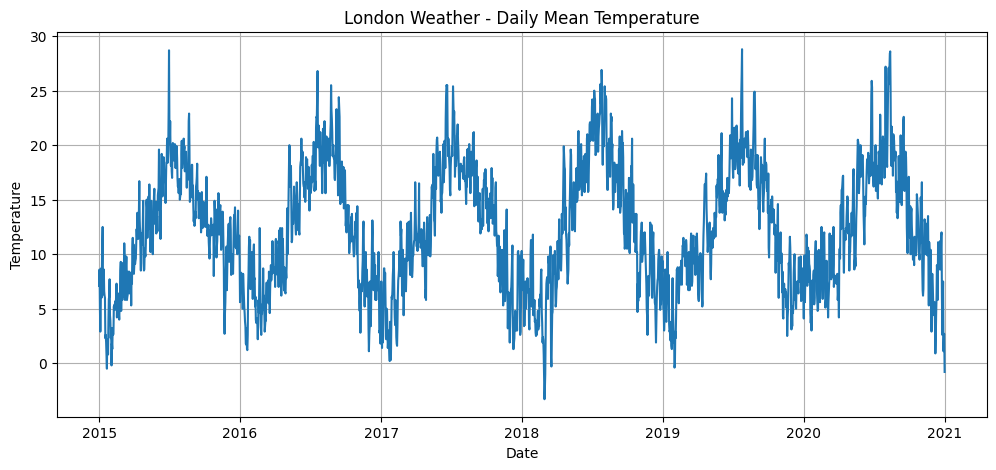

In [4]:
print("Dataset shape:", data.shape)
print("Columns:", list(data.columns))
print("Date range:", data['Date'].min(), "to", data['Date'].max())
print("\nMissing values:")
print(data.isna().sum())

plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Temperature'])
plt.title("London Weather - Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

## 3. Sequence Construction  

We transform the time series into input-output sequences.  
For each sample, the input contains the temperatures from the previous days, and the output is the temperature of the next day.  


In [5]:
values = data['Temperature'].values.reshape(-1, 1)

def create_sequences(data_array, seq_length):
    X, y = [], []
    for i in range(len(data_array) - seq_length):
        X.append(data_array[i:i+seq_length])
        y.append(data_array[i+seq_length])
    return np.array(X), np.array(y)

## 4. Train / Validation / Test Split  

We split the time series in chronological order to avoid information leakage.  

The scaler is fitted only on the training set, and then applied to the validation and test sets.  

In [6]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

SEQ_LENGTHS = [3, 7, 12, 21]
RNN_UNITS = [32, 50, 64]
RNN_LAYERS = [1, 2]
BATCH_SIZE = 16
EPOCHS = 30


def prepare_split(values, seq_length, train_ratio=0.7, val_ratio=0.1):
    train_end = int(len(values) * train_ratio)
    val_end = int(len(values) * (train_ratio + val_ratio))

    scaler_local = MinMaxScaler()
    scaler_local.fit(values[:train_end])

    full_scaled = scaler_local.transform(values)

    X_all, y_all = create_sequences(full_scaled, seq_length)

    train_last_idx = train_end - seq_length
    val_last_idx = val_end - seq_length

    X_train_local = X_all[:train_last_idx]
    y_train_local = y_all[:train_last_idx]

    X_val_local = X_all[train_last_idx:val_last_idx]
    y_val_local = y_all[train_last_idx:val_last_idx]

    X_test_local = X_all[val_last_idx:]
    y_test_local = y_all[val_last_idx:]

    return scaler_local, X_train_local, y_train_local, X_val_local, y_val_local, X_test_local, y_test_local


def inverse_metrics(scaler_local, y_true_scaled, y_pred_scaled):
    y_true_inv = scaler_local.inverse_transform(y_true_scaled.reshape(-1, 1))
    y_pred_inv = scaler_local.inverse_transform(y_pred_scaled.reshape(-1, 1))

    mse = mean_squared_error(y_true_inv, y_pred_inv)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)

    return mse, mae, y_true_inv.flatten(), y_pred_inv.flatten()

## 5. Model Definitions  

We define three architectures for comparison: LSTM, GRU, and CNN.  

LSTM and GRU are recurrent models that are designed to capture temporal dependencies.  

CNN is included because 1D convolutions can also learn local patterns in sequential data.  

In [7]:
def build_lstm_model(seq_length, units=50, n_layers=1, dropout_rate=0.2):
    model = Sequential()

    if n_layers == 1:
        model.add(LSTM(units, input_shape=(seq_length, 1)))
    else:
        model.add(LSTM(units, return_sequences=True, input_shape=(seq_length, 1)))
        for _ in range(n_layers - 2):
            model.add(LSTM(units, return_sequences=True))
        model.add(LSTM(units))

    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_gru_model(seq_length, units=50, n_layers=1, dropout_rate=0.2):
    model = Sequential()

    if n_layers == 1:
        model.add(GRU(units, input_shape=(seq_length, 1)))
    else:
        model.add(GRU(units, return_sequences=True, input_shape=(seq_length, 1)))
        for _ in range(n_layers - 2):
            model.add(GRU(units, return_sequences=True))
        model.add(GRU(units))

    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_cnn_model(seq_length, filters=64, kernel_size=2, dense_units=50, dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=(seq_length, 1)))
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

## 6. Unified Experiment Function  

To keep the notebook organized and reproducible, we create one function to run each experiment.  

The best model settings are selected using validation loss, while the test set is only used for final evaluation.  

In [8]:
def run_single_experiment(model_name, seq_length, units=50, n_layers=1,
                          filters=64, kernel_size=2, dense_units=50,
                          dropout_rate=0.2, verbose_fit=0):

    scaler_local, X_train_local, y_train_local, X_val_local, y_val_local, X_test_local, y_test_local = prepare_split(values, seq_length)

    if model_name == 'LSTM':
        model = build_lstm_model(seq_length=seq_length, units=units, n_layers=n_layers, dropout_rate=dropout_rate)

    elif model_name == 'GRU':
        model = build_gru_model(seq_length=seq_length, units=units, n_layers=n_layers, dropout_rate=dropout_rate)

    elif model_name == 'CNN':
        model = build_cnn_model(seq_length=seq_length, filters=filters, kernel_size=kernel_size,
                                dense_units=dense_units, dropout_rate=dropout_rate)

    else:
        raise ValueError("Unsupported model_name")

    early_stop_local = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_local, y_train_local,
        validation_data=(X_val_local, y_val_local),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_local],
        verbose=verbose_fit
    )

    pred_scaled = model.predict(X_test_local, verbose=0).flatten()
    test_mse, test_mae, y_true_inv, y_pred_inv = inverse_metrics(scaler_local, y_test_local, pred_scaled)

    best_val_loss = min(history.history['val_loss'])

    return {
        'model_name': model_name,
        'seq_length': seq_length,
        'units': units,
        'n_layers': n_layers,
        'filters': filters,
        'kernel_size': kernel_size,
        'dense_units': dense_units,
        'dropout_rate': dropout_rate,
        'best_val_loss': best_val_loss,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'model': model,
        'history': history,
        'X_test': X_test_local,
        'y_test_scaled': y_test_local,
        'y_test_inv': y_true_inv,
        'y_pred_inv': y_pred_inv,
        'scaler': scaler_local
    }

## 7. Hyperparameter Experiments for LSTM  

We test different sequence lengths, hidden units, and numbers of layers for the LSTM model.  
This helps identify the best LSTM configuration for the dataset.  

In [9]:
lstm_hyper_results = []

for seq_len in SEQ_LENGTHS:
    for units in RNN_UNITS:
        for n_layers in RNN_LAYERS:
            result = run_single_experiment(
                model_name='LSTM',
                seq_length=seq_len,
                units=units,
                n_layers=n_layers,
                verbose_fit=0
            )

            lstm_hyper_results.append({
                'Model': 'LSTM',
                'Sequence_Length': result['seq_length'],
                'Units': result['units'],
                'Layers': result['n_layers'],
                'Best_Val_Loss': result['best_val_loss'],
                'Test_MSE': result['test_mse'],
                'Test_MAE': result['test_mae']
            })

lstm_hyper_df = pd.DataFrame(lstm_hyper_results).sort_values(by='Best_Val_Loss').reset_index(drop=True)
display(lstm_hyper_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

,Model,Sequence_Length,Units,Layers,Best_Val_Loss,Test_MSE,Test_MAE
0,LSTM,21,64,1,0.003362,4.832593,1.714430
1,LSTM,21,64,2,0.003385,4.819505,1.706301
2,LSTM,12,64,2,0.003388,4.807476,1.700090
3,LSTM,21,50,2,0.003390,4.875826,1.713799
4,LSTM,12,50,2,0.003398,4.801810,1.703511
5,LSTM,21,32,2,0.003437,4.814973,1.711663
6,LSTM,3,32,2,0.003525,5.026565,1.732972
7,LSTM,7,50,1,0.003560,5.117159,1.757525
8,LSTM,21,50,1,0.003572,5.094031,1.776868
9,LSTM,3,50,2,0.003611,4.961290,1.734905


## 8. Hyperparameter Experiments for GRU  

We perform the same set of experiments for the GRU model.  
This makes the comparison with LSTM more consistent and fair.  

In [10]:
gru_hyper_results = []

for seq_len in SEQ_LENGTHS:
    for units in RNN_UNITS:
        for n_layers in RNN_LAYERS:
            result = run_single_experiment(
                model_name='GRU',
                seq_length=seq_len,
                units=units,
                n_layers=n_layers,
                verbose_fit=0
            )

            gru_hyper_results.append({
                'Model': 'GRU',
                'Sequence_Length': result['seq_length'],
                'Units': result['units'],
                'Layers': result['n_layers'],
                'Best_Val_Loss': result['best_val_loss'],
                'Test_MSE': result['test_mse'],
                'Test_MAE': result['test_mae']
            })

gru_hyper_df = pd.DataFrame(gru_hyper_results).sort_values(by='Best_Val_Loss').reset_index(drop=True)
display(gru_hyper_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

,Model,Sequence_Length,Units,Layers,Best_Val_Loss,Test_MSE,Test_MAE
0,GRU,21,32,1,0.003293,4.843241,1.704301
1,GRU,21,64,1,0.003301,4.878298,1.708969
2,GRU,21,50,1,0.003301,4.889331,1.711520
3,GRU,21,32,2,0.003308,4.845454,1.691131
4,GRU,21,50,2,0.003327,4.812556,1.694594
5,GRU,12,64,1,0.003333,4.864679,1.704417
6,GRU,21,64,2,0.003338,4.814212,1.697029
7,GRU,12,32,2,0.003340,4.983584,1.716205
8,GRU,12,50,2,0.003356,4.933734,1.703998
9,GRU,12,64,2,0.003371,4.868502,1.698639


## 9. Hyperparameter Experiments for CNN  

For CNN, we tune the sequence length, the number of filters, and the kernel size.  

This allows us to build a stronger CNN baseline for comparison with the recurrent models.  

In [11]:
cnn_hyper_results = []

for seq_len in [7, 12]:
    for filters in [32, 64]:
        for kernel_size in [2, 3]:
            result = run_single_experiment(
                model_name='CNN',
                seq_length=seq_len,
                filters=filters,
                kernel_size=kernel_size,
                dense_units=50,
                verbose_fit=0
            )

            cnn_hyper_results.append({
                'Model': 'CNN',
                'Sequence_Length': result['seq_length'],
                'Filters': result['filters'],
                'Kernel_Size': result['kernel_size'],
                'Best_Val_Loss': result['best_val_loss'],
                'Test_MSE': result['test_mse'],
                'Test_MAE': result['test_mae']
            })

cnn_hyper_df = pd.DataFrame(cnn_hyper_results).sort_values(by='Best_Val_Loss').reset_index(drop=True)
display(cnn_hyper_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

,Model,Sequence_Length,Filters,Kernel_Size,Best_Val_Loss,Test_MSE,Test_MAE
0,CNN,12,32,3,0.003397,4.918390,1.727774
1,CNN,12,32,2,0.003402,4.850377,1.721934
2,CNN,7,32,2,0.003500,4.885089,1.738253
3,CNN,12,64,2,0.003513,4.874341,1.724480
4,CNN,12,64,3,0.003513,4.905915,1.739133
5,CNN,7,64,2,0.003936,5.115681,1.772107
6,CNN,7,64,3,0.004105,5.214280,1.809973
7,CNN,7,32,3,0.004925,5.956862,1.918928


In [12]:
import pandas as pd

best_lstm = lstm_hyper_df.head(1).copy()
best_gru = gru_hyper_df.head(1).copy()

rnn_comparison_df = pd.concat([best_lstm, best_gru], ignore_index=True)

print(rnn_comparison_df)

  Model  Sequence_Length  Units  Layers  Best_Val_Loss  Test_MSE  Test_MAE
0  LSTM               21     64       1       0.003362  4.832593  1.714430
1   GRU               21     32       1       0.003293  4.843241  1.704301


## 10. Best Baseline Models  

We select the best LSTM, GRU, and CNN configurations based on validation loss.  

This provides a clear baseline before applying attention.  

In [13]:
best_lstm_row = lstm_hyper_df.iloc[0]
best_gru_row = gru_hyper_df.iloc[0]
best_cnn_row = cnn_hyper_df.iloc[0]

final_best_models_df = pd.DataFrame([
    {
        'Model': 'Best LSTM',
        'Sequence_Length': best_lstm_row['Sequence_Length'],
        'Key_Params': f"units={best_lstm_row['Units']}, layers={best_lstm_row['Layers']}",
        'Best_Val_Loss': best_lstm_row['Best_Val_Loss'],
        'Test_MSE': best_lstm_row['Test_MSE'],
        'Test_MAE': best_lstm_row['Test_MAE']
    },
    {
        'Model': 'Best GRU',
        'Sequence_Length': best_gru_row['Sequence_Length'],
        'Key_Params': f"units={best_gru_row['Units']}, layers={best_gru_row['Layers']}",
        'Best_Val_Loss': best_gru_row['Best_Val_Loss'],
        'Test_MSE': best_gru_row['Test_MSE'],
        'Test_MAE': best_gru_row['Test_MAE']
    },
    {
        'Model': 'Best CNN',
        'Sequence_Length': best_cnn_row['Sequence_Length'],
        'Key_Params': f"filters={best_cnn_row['Filters']}, kernel_size={best_cnn_row['Kernel_Size']}",
        'Best_Val_Loss': best_cnn_row['Best_Val_Loss'],
        'Test_MSE': best_cnn_row['Test_MSE'],
        'Test_MAE': best_cnn_row['Test_MAE']
    }
]).sort_values(by='Best_Val_Loss').reset_index(drop=True)

display(final_best_models_df)

,Model,Sequence_Length,Key_Params,Best_Val_Loss,Test_MSE,Test_MAE
0,Best GRU,21,"units=32, layers=1",0.003293,4.843241,1.704301
1,Best LSTM,21,"units=64, layers=1",0.003362,4.832593,1.714430
2,Best CNN,12,"filters=32, kernel_size=3",0.003397,4.918390,1.727774


## 11. Retraining the Best CNN  

To compare the final best CNN with the best recurrent model, we retrain the selected CNN configuration.  
This also allows us to store its history and predictions for later analysis.  

In [14]:
best_cnn_seq_len = int(best_cnn_row['Sequence_Length'])
best_cnn_filters = int(best_cnn_row['Filters'])
best_cnn_kernel = int(best_cnn_row['Kernel_Size'])

best_cnn_result = run_single_experiment(
    model_name='CNN',
    seq_length=best_cnn_seq_len,
    filters=best_cnn_filters,
    kernel_size=best_cnn_kernel,
    dense_units=50,
    verbose_fit=0
)

print("Best CNN selected by validation loss:")
print("Sequence length:", best_cnn_seq_len)
print("Filters:", best_cnn_filters)
print("Kernel size:", best_cnn_kernel)
print("Validation loss:", best_cnn_result['best_val_loss'])
print("Test MSE:", best_cnn_result['test_mse'])
print("Test MAE:", best_cnn_result['test_mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best CNN selected by validation loss:
Sequence length: 12
Filters: 32
Kernel size: 3
Validation loss: 0.0034575725439935923
Test MSE: 4.92205545357311
Test MAE: 1.726803774811906


## 12. Attention on the Best-Performing RNN  

Next, we identify the best recurrent baseline
Then we add an attention mechanism on top of that recurrent architecture.  

In [15]:
best_lstm_val = best_lstm_row['Best_Val_Loss']
best_gru_val = best_gru_row['Best_Val_Loss']

if best_lstm_val <= best_gru_val:
    best_base_model_name = 'LSTM'
    best_base_seq_len = int(best_lstm_row['Sequence_Length'])
    best_base_units = int(best_lstm_row['Units'])
    best_base_layers = int(best_lstm_row['Layers'])
else:
    best_base_model_name = 'GRU'
    best_base_seq_len = int(best_gru_row['Sequence_Length'])
    best_base_units = int(best_gru_row['Units'])
    best_base_layers = int(best_gru_row['Layers'])

baseline_best_rnn = run_single_experiment(
    model_name=best_base_model_name,
    seq_length=best_base_seq_len,
    units=best_base_units,
    n_layers=best_base_layers,
    verbose_fit=0
)

print("Best baseline RNN selected by validation loss:")
print("Model:", best_base_model_name)
print("Sequence length:", best_base_seq_len)
print("Units:", best_base_units)
print("Layers:", best_base_layers)
print("Validation loss:", baseline_best_rnn['best_val_loss'])
print("Test MSE:", baseline_best_rnn['test_mse'])
print("Test MAE:", baseline_best_rnn['test_mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best baseline RNN selected by validation loss:
Model: GRU
Sequence length: 21
Units: 32
Layers: 1
Validation loss: 0.0033017087262123823
Test MSE: 4.852919372217138
Test MAE: 1.704776570241745


## 13. Attention Model Definition  

The attention model first encodes the sequence with a recurrent layer and then learns which time steps are more important for the prediction.  
This gives both performance comparison and interpretability.  

In [16]:
def build_attention_model(base_model_name, seq_length, units=64, dropout_rate=0.2):
    inputs = Input(shape=(seq_length, 1), name='input_sequence')

    if base_model_name == 'LSTM':
        seq_output = LSTM(units, return_sequences=True, name='memory_layer')(inputs)
    elif base_model_name == 'GRU':
        seq_output = GRU(units, return_sequences=True, name='memory_layer')(inputs)
    else:
        raise ValueError("base_model_name must be 'LSTM' or 'GRU'")

    attention_scores = Dense(1, activation='tanh', name='attention_score')(seq_output)
    attention_weights = Softmax(axis=1, name='attention_weights')(attention_scores)

    weighted_sequence = Multiply(name='weighted_sequence')([seq_output, attention_weights])
    context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1), name='context_vector')(weighted_sequence)

    x = Dropout(dropout_rate)(context_vector)
    output = Dense(1, name='prediction')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mse')

    attention_extractor = Model(inputs=inputs, outputs=attention_weights)

    return model, attention_extractor

## 14. Training the Attention Model  

We train the attention-based model using the same best sequence length and hidden size as the best recurrent baseline.  
This makes the comparison more consistent.  

In [17]:
att_scaler, X_train_att, y_train_att, X_val_att, y_val_att, X_test_att, y_test_att = prepare_split(values, best_base_seq_len)

attention_model, attention_extractor = build_attention_model(
    base_model_name=best_base_model_name,
    seq_length=best_base_seq_len,
    units=best_base_units,
    dropout_rate=0.2
)

early_stop_att = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_attention = attention_model.fit(
    X_train_att, y_train_att,
    validation_data=(X_val_att, y_val_att),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_att],
    verbose=0
)

attention_pred_scaled = attention_model.predict(X_test_att, verbose=0).flatten()
attention_mse, attention_mae, y_test_att_inv, attention_pred_inv = inverse_metrics(
    att_scaler, y_test_att, attention_pred_scaled
)

attention_val_loss = min(history_attention.history['val_loss'])

attention_results_df = pd.DataFrame([
    {
        'Model': f'{best_base_model_name} + Attention',
        'Sequence_Length': best_base_seq_len,
        'Units': best_base_units,
        'Best_Val_Loss': attention_val_loss,
        'Test_MSE': attention_mse,
        'Test_MAE': attention_mae
    }
])

display(attention_results_df)

,Model,Sequence_Length,Units,Best_Val_Loss,Test_MSE,Test_MAE
0,GRU + Attention,21,32,0.007202,9.413544,2.45459


## 15. Baseline RNN vs Attention  

We compare the predictions of the best recurrent baseline and the attention-based version on the test set.  

This helps us see whether attention improves the forecasting behavior.  

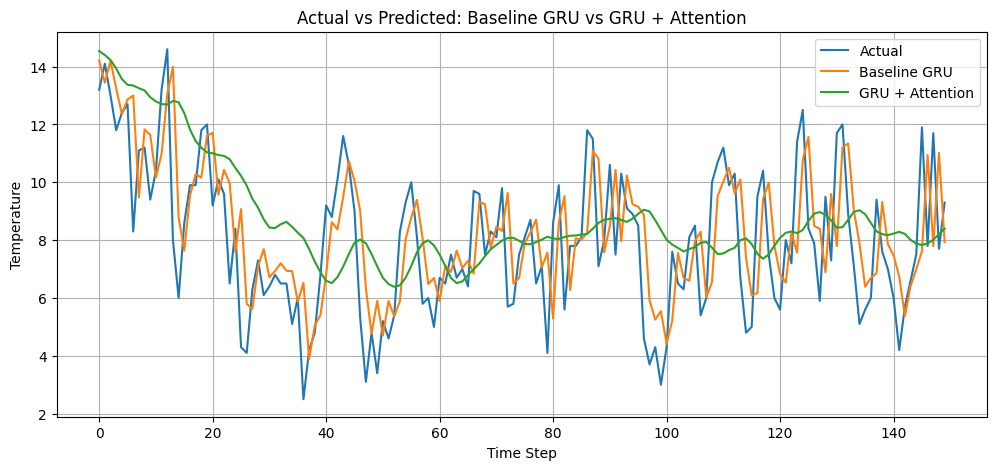

In [18]:
plt.figure(figsize=(12,5))
plt.plot(y_test_att_inv[:150], label='Actual')
plt.plot(baseline_best_rnn['y_pred_inv'][:150], label=f'Baseline {best_base_model_name}')
plt.plot(attention_pred_inv[:150], label=f'{best_base_model_name} + Attention')
plt.title(f'Actual vs Predicted: Baseline {best_base_model_name} vs {best_base_model_name} + Attention')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

## 16. How Attention Works: Examples  

To illustrate how attention works, we extract the attention weights for several test samples.  

These weights show which input time steps receive more importance during prediction.  

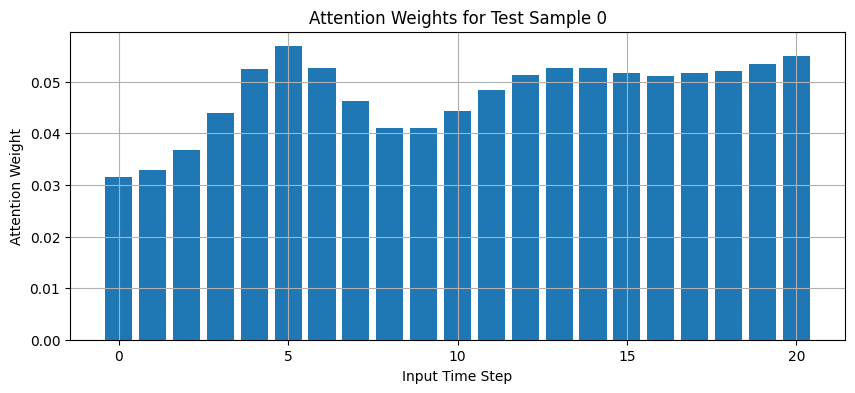

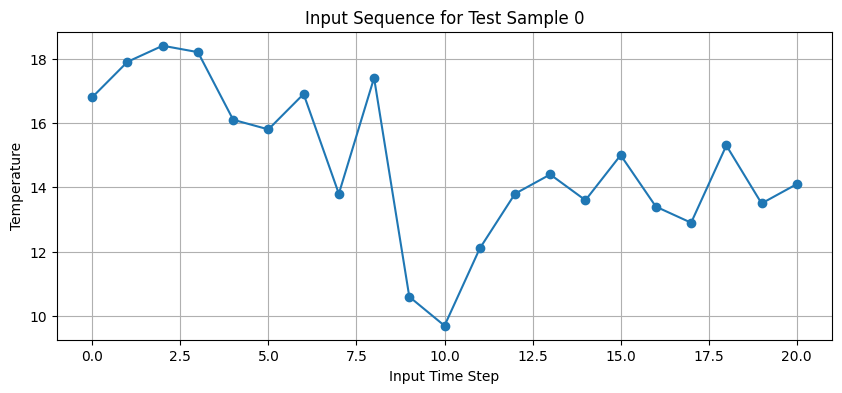

True next temperature for sample 0: 13.200
Predicted next temperature for sample 0: 14.537
------------------------------------------------------------


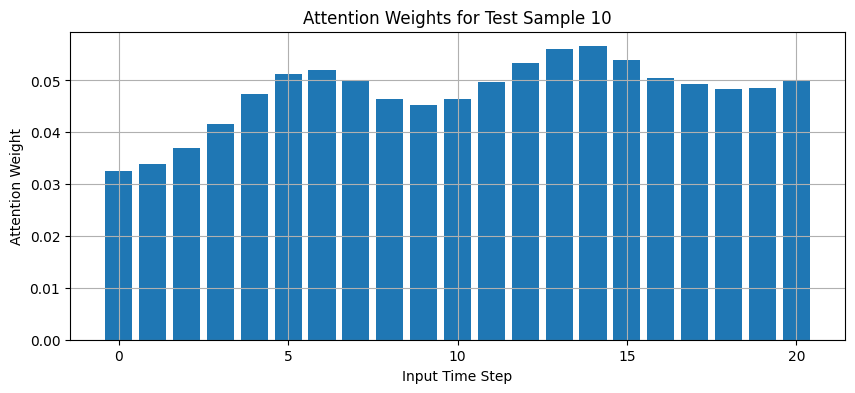

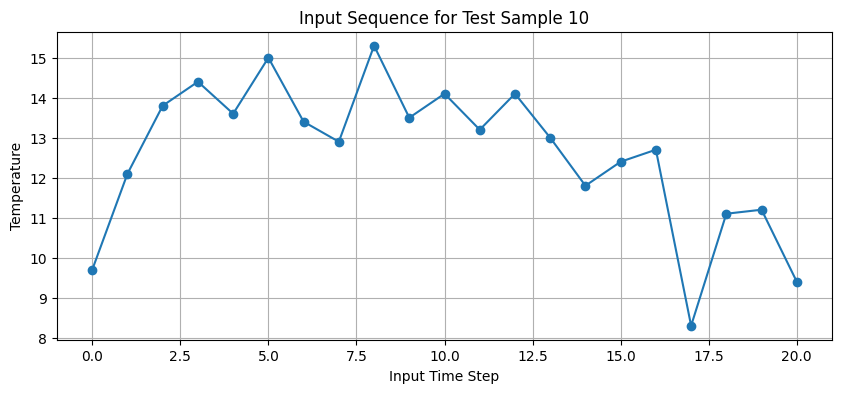

True next temperature for sample 10: 10.400
Predicted next temperature for sample 10: 12.796
------------------------------------------------------------


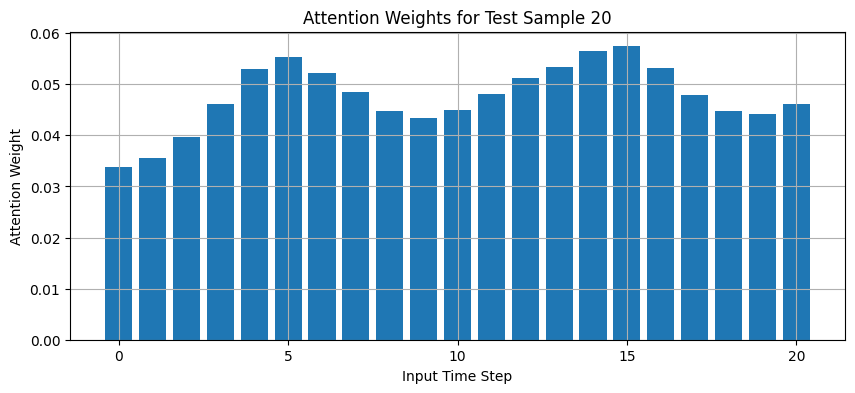

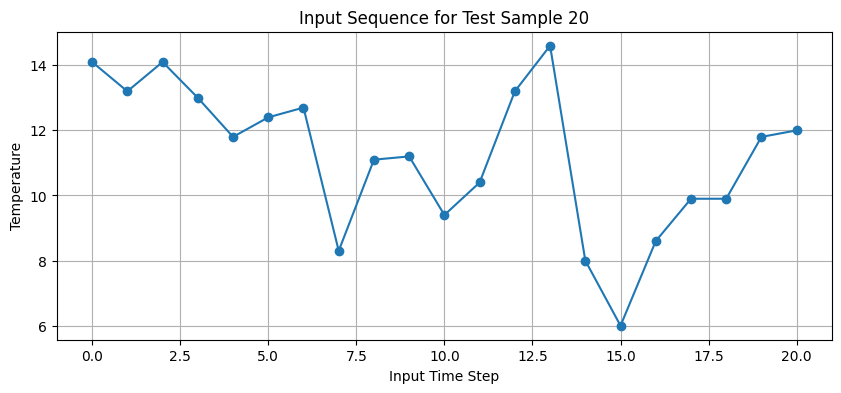

True next temperature for sample 20: 9.200
Predicted next temperature for sample 20: 11.004
------------------------------------------------------------


In [19]:
sample_indices = [0, 10, 20]
attention_weights_examples = attention_extractor.predict(X_test_att[sample_indices], verbose=0)

for i, idx in enumerate(sample_indices):
    weights = attention_weights_examples[i].flatten()
    input_sequence_inv = att_scaler.inverse_transform(X_test_att[idx].reshape(-1,1)).flatten()

    plt.figure(figsize=(10,4))
    plt.bar(range(len(weights)), weights)
    plt.title(f'Attention Weights for Test Sample {idx}')
    plt.xlabel('Input Time Step')
    plt.ylabel('Attention Weight')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(input_sequence_inv, marker='o')
    plt.title(f'Input Sequence for Test Sample {idx}')
    plt.xlabel('Input Time Step')
    plt.ylabel('Temperature')
    plt.grid(True)
    plt.show()

    print(f"True next temperature for sample {idx}: {y_test_att_inv[idx]:.3f}")
    print(f"Predicted next temperature for sample {idx}: {attention_pred_inv[idx]:.3f}")
    print("-" * 60)

## 17. CNN Prediction Plot  
For completeness, we also visualize the predictions of the best CNN model on the test set.  
This makes it easier to compare CNN with the recurrent approaches.  

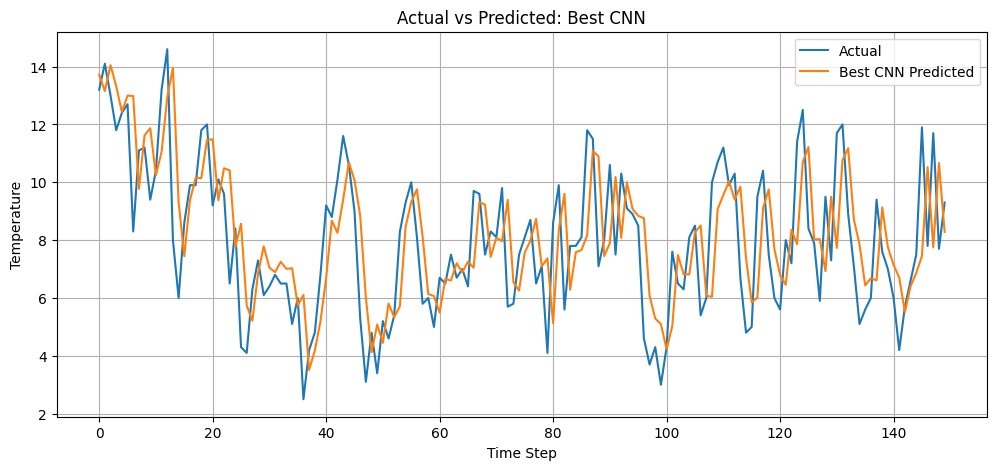

In [20]:
plt.figure(figsize=(12,5))
plt.plot(best_cnn_result['y_test_inv'][:150], label='Actual')
plt.plot(best_cnn_result['y_pred_inv'][:150], label='Best CNN Predicted')
plt.title('Actual vs Predicted: Best CNN')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

## 18. Loss Curves  

Finally, we plot the training and validation loss curves for the best baseline RNN, the attention model, and the best CNN.  
These plots help us check convergence and possible overfitting.  


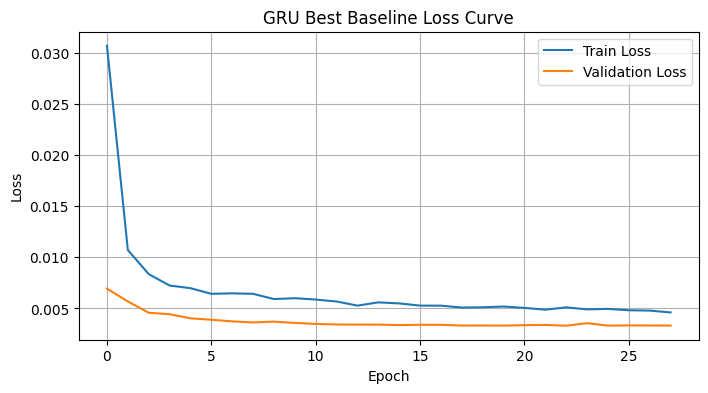

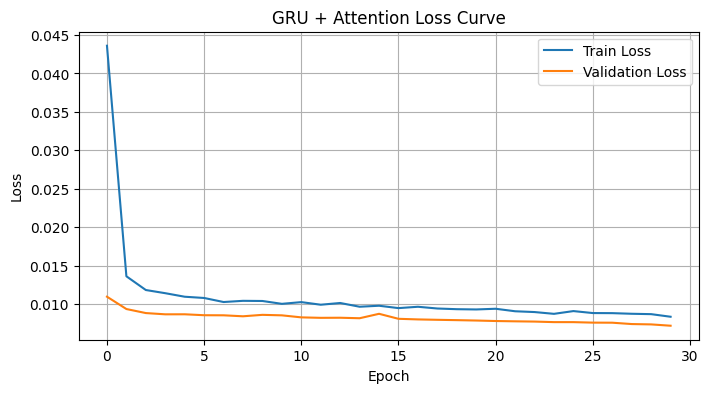

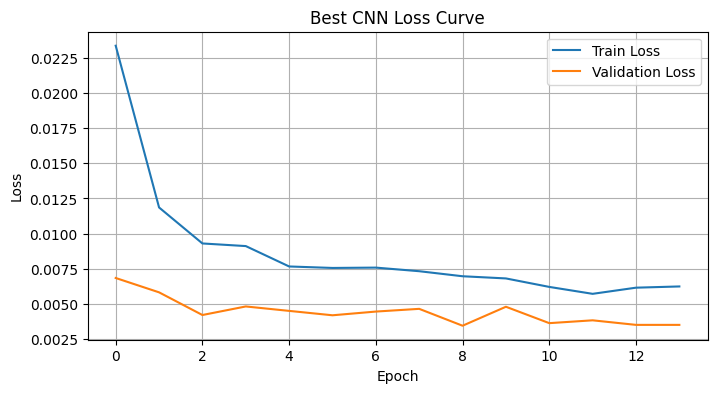

In [21]:
def plot_loss_curve(history, title):
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curve(baseline_best_rnn['history'], f'{best_base_model_name} Best Baseline Loss Curve')
plot_loss_curve(history_attention, f'{best_base_model_name} + Attention Loss Curve')
plot_loss_curve(best_cnn_result['history'], 'Best CNN Loss Curve')

## 19. Final Comparison  

We now summarize the final performance of the best baseline RNN, the attention-enhanced RNN, and the best CNN.  

This table will be useful in the report for discussing the overall findings.  

In [22]:
final_comparison_df = pd.DataFrame([
    {
        'Model': f'Best Baseline {best_base_model_name}',
        'Best_Val_Loss': baseline_best_rnn['best_val_loss'],
        'Test_MSE': baseline_best_rnn['test_mse'],
        'Test_MAE': baseline_best_rnn['test_mae']
    },
    {
        'Model': f'{best_base_model_name} + Attention',
        'Best_Val_Loss': attention_val_loss,
        'Test_MSE': attention_mse,
        'Test_MAE': attention_mae
    },
    {
        'Model': 'Best CNN',
        'Best_Val_Loss': best_cnn_result['best_val_loss'],
        'Test_MSE': best_cnn_result['test_mse'],
        'Test_MAE': best_cnn_result['test_mae']
    }
]).sort_values(by='Best_Val_Loss').reset_index(drop=True)

display(final_comparison_df)

,Model,Best_Val_Loss,Test_MSE,Test_MAE
0,Best Baseline GRU,0.003302,4.852919,1.704777
1,Best CNN,0.003458,4.922055,1.726804
2,GRU + Attention,0.007202,9.413544,2.454590


## 20. Model Summaries  

To support the architectural comparison in the report, we display the summaries of the best baseline RNN, the attention model, and the best CNN.  

These summaries are useful for explaining the differences between the architectures.  

In [23]:
print("Best baseline RNN summary")
baseline_best_rnn['model'].summary()

print("\nAttention model summary")
attention_model.summary()

print("\nBest CNN summary")
best_cnn_result['model'].summary()

Best baseline RNN summary


Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_36 (GRU)                    │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 3,393 (13.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 50)             │        16,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,689 (190.20 KB)

 Trainable params: 16,229 (63.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,460 (126.80 KB)